# Computer Vision 1: Assignment 3

Task 1

Group Number 43

Marek Drwal

15.12.2025

## setup

In [55]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## defs

In [56]:
def show_img(img, pth='', comment='', show=True):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    if show:
        plt.show()

In [57]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

## imgs

In [58]:
pth = 'coins.jpg'

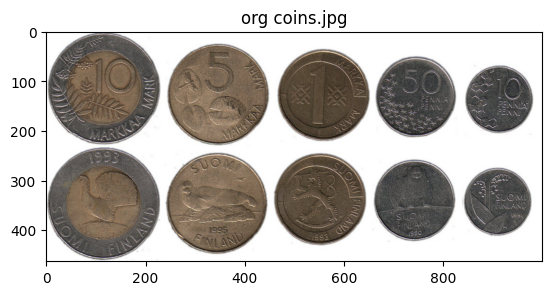

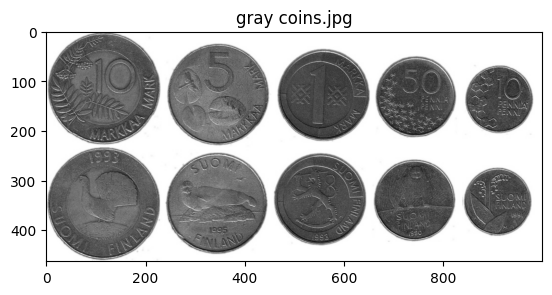

In [59]:
img = load_display_img(pth)

## radii

In [60]:
resolution = 0.12 ## mm/px

In [61]:
rs = [27.25, 24.5, 22.25, 19.7, 16.3]
rs = [r/2/resolution for r in rs]
rs

[113.54166666666667,
 102.08333333333334,
 92.70833333333334,
 82.08333333333333,
 67.91666666666667]

## Canny

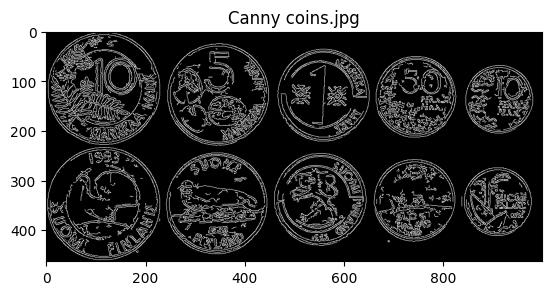

In [62]:
img_edge = ski.feature.canny(img)
show_img(img_edge, pth, 'Canny')

## Hough circle

In [63]:
h_circles = ski.transform.hough_circle(img_edge, rs)

In [64]:
h_circles.shape

(5, 463, 1000)

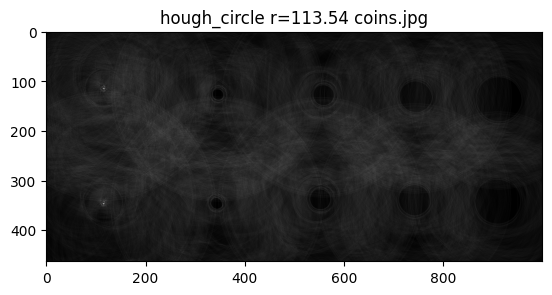

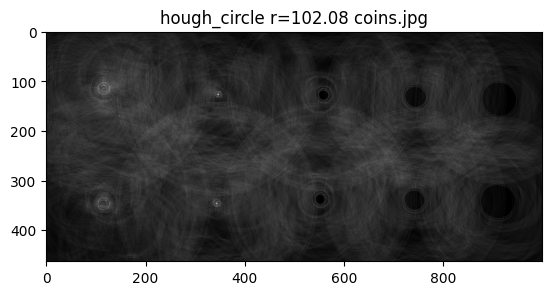

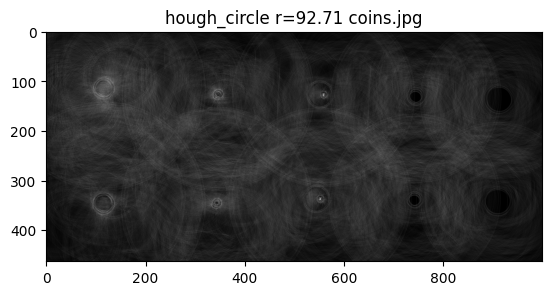

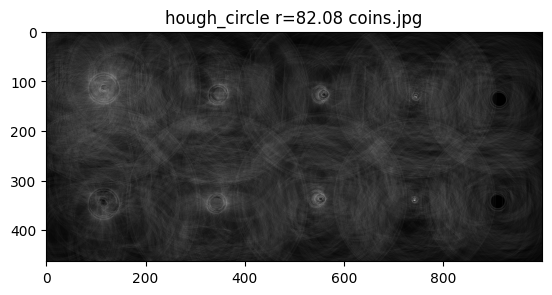

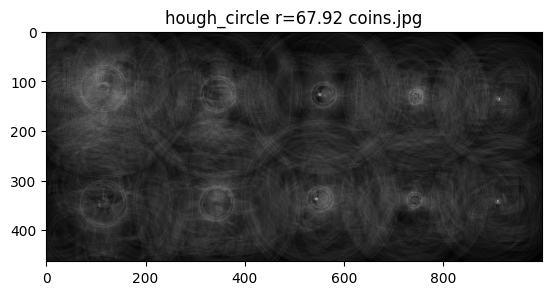

In [65]:
for im, r in zip(h_circles, rs):
    show_img(im, pth, f'hough_circle r={r:.2f}')

## Hough circle peaks

In [66]:
accums, cx, cy, radii = ski.transform.hough_circle_peaks(h_circles, rs, num_peaks=2, total_num_peaks=10, normalize=True)

In [67]:
accums

array([0.61197917, 0.55208333, 0.58898305, 0.78240741, 0.62689394,
       0.57007576, 0.68518519, 0.59075342, 0.54452055, 0.38559322])

In [68]:
cx

array([910, 914, 743, 116, 559, 552, 116, 343, 346, 743])

In [69]:
cy

array([341, 135, 340, 347, 129, 338, 115, 346, 127, 131])

In [70]:
radii

array([ 67.91666667,  67.91666667,  82.08333333, 113.54166667,
        92.70833333,  92.70833333, 113.54166667, 102.08333333,
       102.08333333,  82.08333333])

### vis

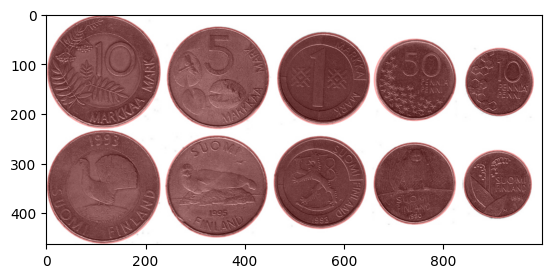

In [71]:
fig, ax = plt.subplots()
im = ax.imshow(img, cmap=plt.cm.gray)
for x, y, r, acc in zip(cx, cy, radii, accums):
    patch = Circle((x,y), r, alpha=.2, fill=True, transform=ax.transData, color='r')
    ax.add_patch(patch)

plt.show()